## Carga de datos y visualización de compras y ventas de las familias comercializadas por la empresa

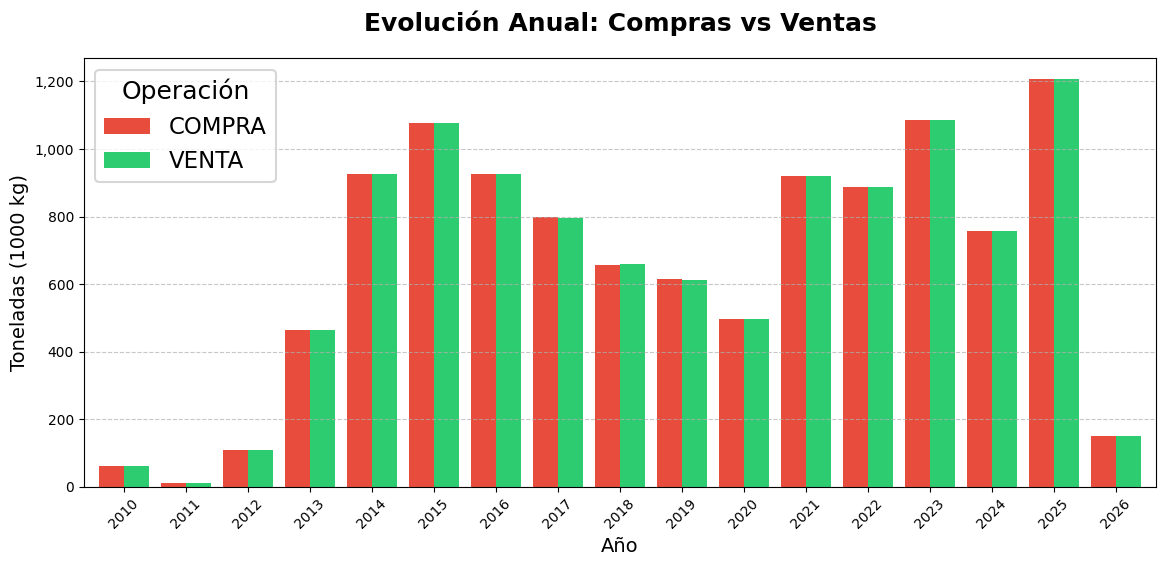

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Cargar datos
df = pd.read_excel('../data/processed/datos.xlsx')

# 2. Crear columna de AÑO
df['AÑO'] = df['FECHA'].dt.year

# 3. Agrupar por Año y Tipo de Operación y DIVIDIR ENTRE 1000
# Esto convierte los Euros en "Miles de Euros"
resumen_anual_k = df.groupby(['AÑO', 'TIPO_OPERACION'])['PESO_BRUTO'].sum().unstack() / 1000

# 4. Gráfico profesional
# Nota: Quitamos el plt.figure previo porque pandas.plot crea su propia figura con figsize
ax = resumen_anual_k.plot(kind='bar', figsize=(12, 6), color=['#e74c3c', '#2ecc71'], width=0.8)

# Configuración de estética
sns.set_context("talk") 
plt.title('Evolución Anual: Compras vs Ventas', fontsize=18, pad=20, fontweight='bold')
plt.ylabel('Toneladas (1000 kg)', fontsize=14)
plt.xlabel('Año', fontsize=14)
plt.xticks(rotation=45) # Rotamos un poco para que no se choquen si hay muchos años
plt.legend(title='Operación', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatear el eje Y para que ponga el separador de miles (ej: 1.500 en vez de 1500)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

## Visualización de Estacionalidad de Ventas en Toneladas (variable no monetaria) de la suma de las 3 familias por mes y año

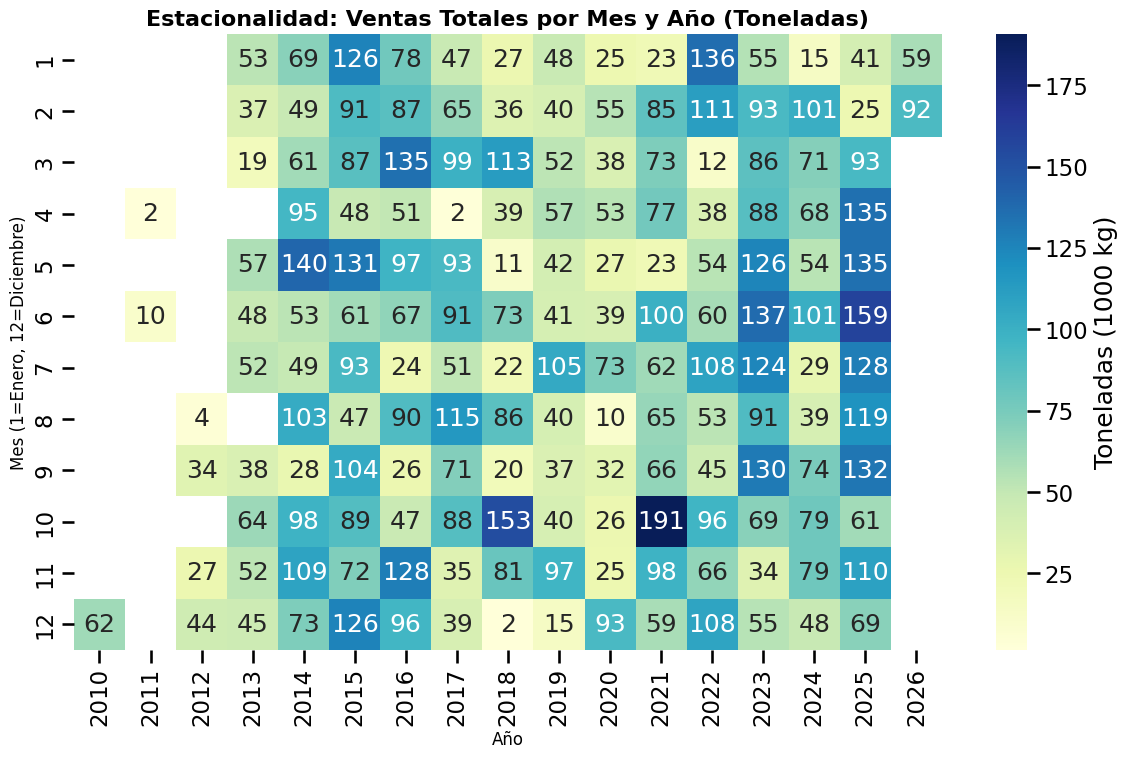

In [2]:
# Preparar datos: Solo Ventas y crear columnas de Año y Mes
df_ventas = df[df['TIPO_OPERACION'] == 'VENTA'].copy()
df_ventas['AÑO'] = df_ventas['FECHA'].dt.year
df_ventas['MES'] = df_ventas['FECHA'].dt.month

# Crear matriz para el Heatmap (Meses en filas, Años en columnas)
matrix = df_ventas.pivot_table(index='MES', columns='AÑO', values='PESO_BRUTO', aggfunc='sum') / 1000

plt.figure(figsize=(14, 8))
# Corregido: usamos cbar_kws con un diccionario para el label
sns.heatmap(matrix, annot=True, fmt=".0f", cmap="YlGnBu", 
            cbar_kws={'label': 'Toneladas (1000 kg)'})

plt.title('Estacionalidad: Ventas Totales por Mes y Año (Toneladas)', fontsize=16, fontweight='bold')
plt.ylabel('Mes (1=Enero, 12=Diciembre)', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.show()

## Visualización de Estacionalidad de Ventas en Toneladas (variable no monetaria) por familia individual por mes y año

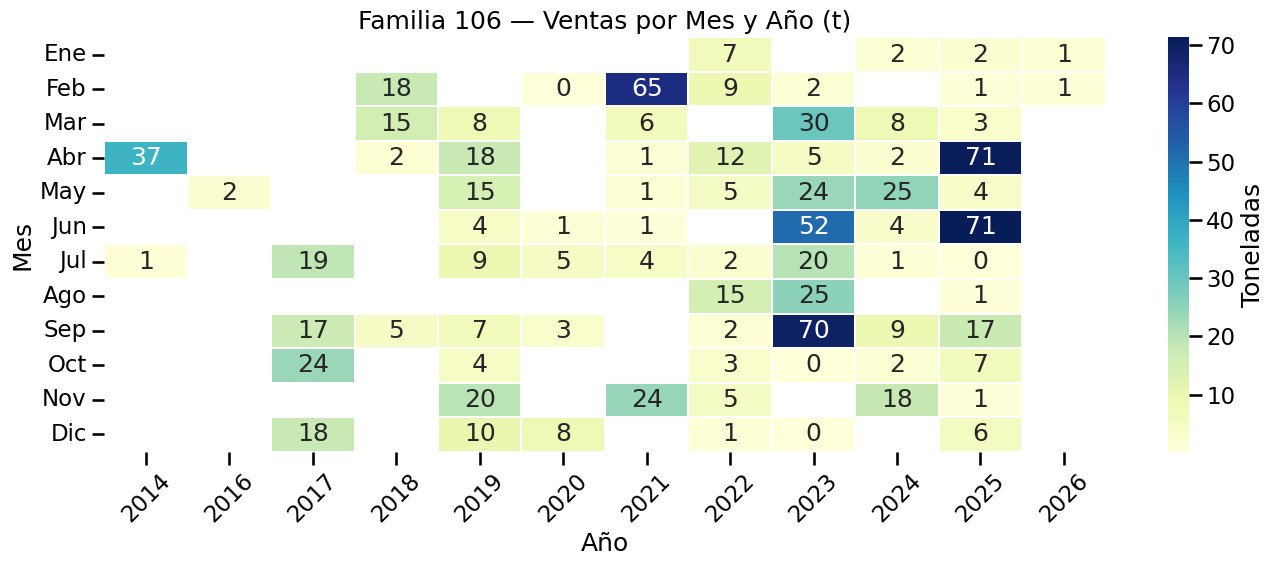

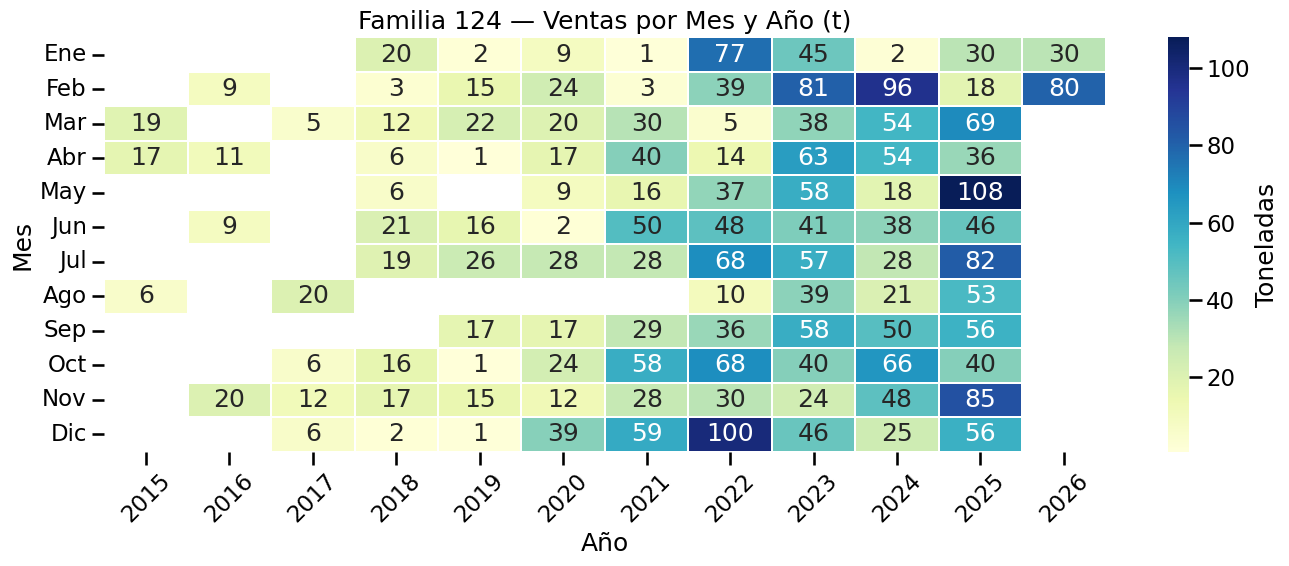

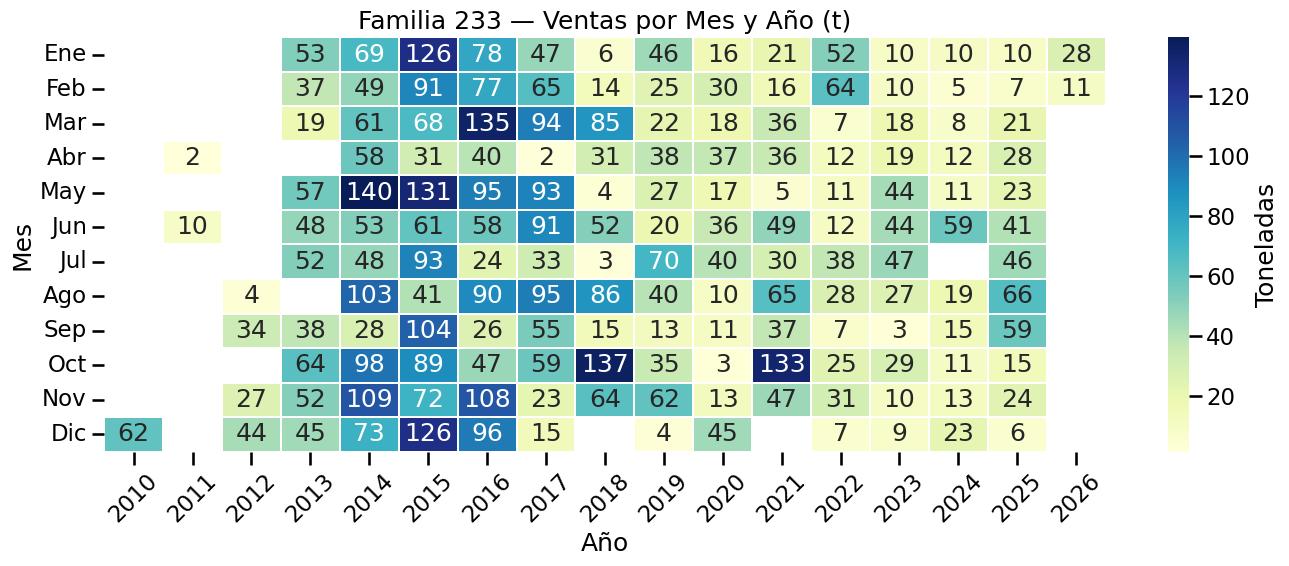

In [3]:
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

df_v = df[df['TIPO_OPERACION'] == 'VENTA'].copy()
df_v['AÑO'] = df_v['FECHA'].dt.year
df_v['MES'] = df_v['FECHA'].dt.month

for fam in sorted(df_v['FAMILIA'].unique()):
    mat = df_v[df_v['FAMILIA'] == fam].pivot_table(
        index='MES', columns='AÑO', values='PESO_BRUTO', aggfunc='sum'
    ) / 1000
    mat.index = [MESES[m-1] for m in mat.index]

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(mat, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
                linewidths=0.3, cbar_kws={'label': 'Toneladas'})
    ax.set(title=f'Familia {fam} — Ventas por Mes y Año (t)',
           xlabel='Año', ylabel='Mes')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig(f'../figuras/heatmap_{fam}.pdf', bbox_inches='tight')
    plt.show()

## Visualización de correlación de Pearscon entre las variables de ventas en Kilos e importe

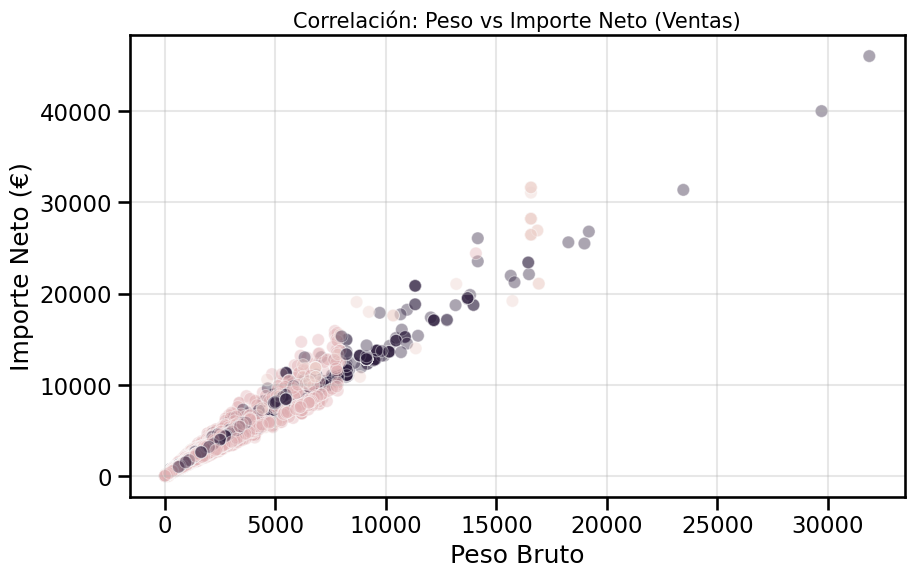

Coeficiente de correlación de Pearson: 0.98


In [4]:
plt.figure(figsize=(10, 6))
# Quitamos los logaritmos si tus datos son más o menos estables
sns.scatterplot(data=df_ventas, x='PESO_BRUTO', y='IMPORTE_NETO', alpha=0.4, hue='FAMILIA', legend=False)
plt.title('Correlación: Peso vs Importe Neto (Ventas)', fontsize=15)
plt.xlabel('Peso Bruto')
plt.ylabel('Importe Neto (€)')
plt.grid(True, alpha=0.3)
plt.show()

corr = df_ventas['PESO_BRUTO'].corr(df_ventas['IMPORTE_NETO'])
print(f"Coeficiente de correlación de Pearson: {corr:.2f}")

## Análisis de Autocorrelación de los últimos 24 meses

<Figure size 1000x500 with 0 Axes>

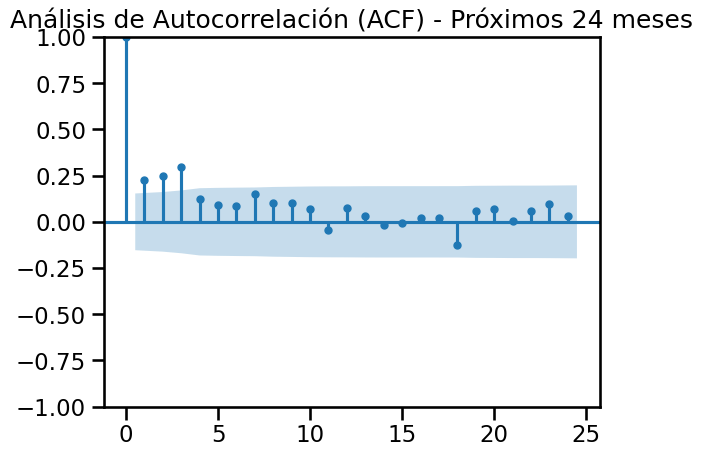

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

# Agrupamos por mes
serie_temporal = df_ventas.groupby(df_ventas['FECHA'].dt.to_period('M'))['PESO_BRUTO'].sum()

# Dibujamos la autocorrelación de los últimos 24 meses (2 años)
plt.figure(figsize=(10, 5))
plot_acf(serie_temporal, lags=24)
plt.title('Análisis de Autocorrelación (ACF) - Próximos 24 meses')
plt.show()

## Análisis PCA y visualización

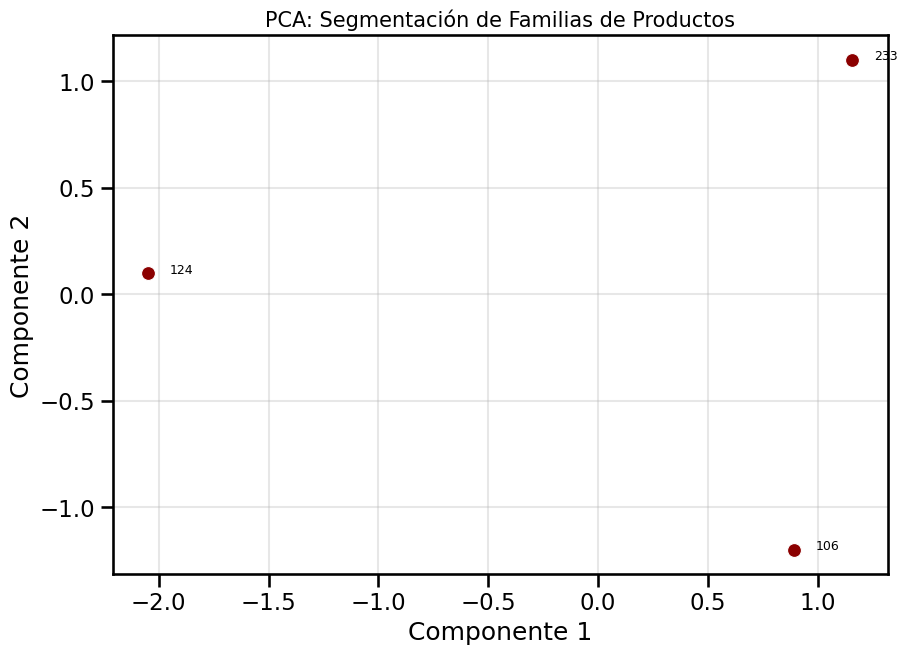

Varianza explicada por los 2 componentes: 100.00%


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparar datos: Queremos ver cómo se comportan las Familias
# Calculamos: Importe medio, Peso medio y Número de ventas por familia
pca_data = df_ventas.groupby('FAMILIA').agg({
    'IMPORTE_NETO': 'mean',
    'PESO_BRUTO': 'mean',
    'FECHA': 'count' # Frecuencia de ventas
}).rename(columns={'FECHA': 'FRECUENCIA'})

# 2. Normalizar (Muy importante: PCA es sensible a las escalas)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# 3. Ejecutar PCA (Reducir a 2 componentes para poder graficar)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# 4. Crear DataFrame para el gráfico
pca_df = pd.DataFrame(data=pca_result, columns=['Componente 1', 'Componente 2'])
pca_df['FAMILIA'] = pca_data.index

# 5. Visualizar
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='Componente 1', y='Componente 2', s=100, color='darkred')

# Añadir etiquetas a los puntos para saber qué familia es cada una
for i in range(pca_df.shape[0]):
    plt.text(pca_df['Componente 1'][i]+0.1, pca_df['Componente 2'][i], 
             pca_df['FAMILIA'][i], fontsize=9)

plt.title('PCA: Segmentación de Familias de Productos', fontsize=15)
plt.grid(True, alpha=0.3)
plt.show()

# Explicación de las varianzas
print(f"Varianza explicada por los 2 componentes: {sum(pca.explained_variance_ratio_)*100:.2f}%")

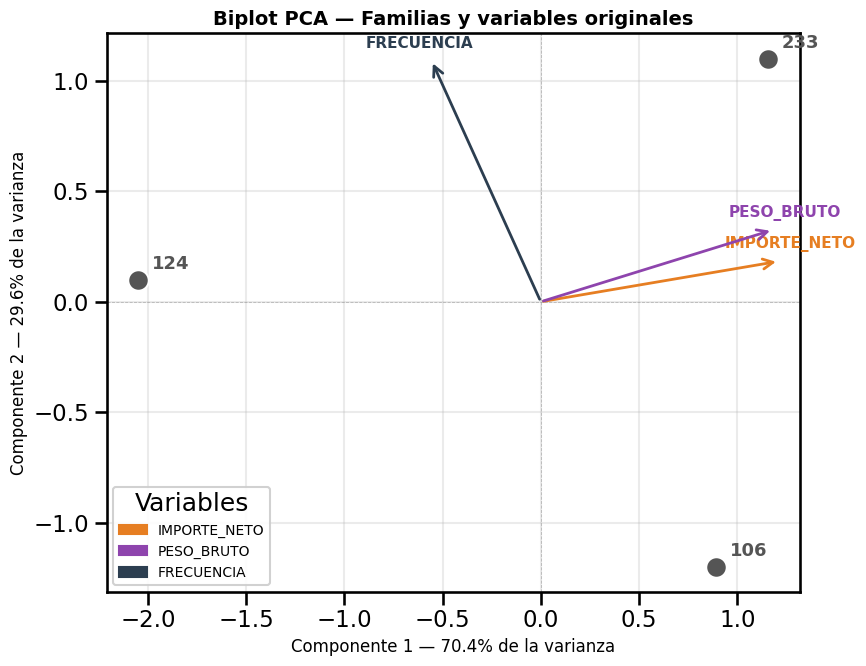

Figura guardada: figuras/pca_biplot.pdf


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Reutilizar los objetos ya calculados en Cell 4 ───────────────────────────
# pca, pca_data, scaled_data, pca_result ya existen

variables  = list(pca_data.columns)          # ['IMPORTE_NETO', 'PESO_BRUTO', 'FRECUENCIA']
familias   = list(pca_data.index)            # ['PE', 'PE-X', 'PVC']
coords     = pca_result                      # coordenadas de cada familia

# Loadings: correlacion de cada variable con cada componente
# shape (n_variables, n_componentes)
loadings   = pca.components_.T

# Escalar flechas al mismo rango que los puntos
scale      = np.sqrt(pca.explained_variance_)
arrows     = loadings * scale

# ── Colores ──────────────────────────────────────────────────────────────────
COLORES_FAM = {'PVC': '#2ecc71', 'PE': '#3498db', 'PE-X': '#e74c3c'}
COLORES_VAR = {
    'IMPORTE_NETO': '#e67e22',
    'PESO_BRUTO'  : '#8e44ad',
    'FRECUENCIA'  : '#2c3e50'
}

# ── Biplot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

# -- Puntos: una familia por punto --
for i, familia in enumerate(familias):
    color = COLORES_FAM.get(familia, '#555')
    ax.scatter(coords[i, 0], coords[i, 1],
               s=220, color=color, zorder=5,
               edgecolors='white', linewidths=1.5)
    ax.annotate(
        familia,
        xy     = (coords[i, 0], coords[i, 1]),
        xytext = (10, 8),
        textcoords='offset points',
        fontsize=13, fontweight='bold', color=color
    )

# -- Flechas: una por variable original --
for i, var in enumerate(variables):
    color_var = COLORES_VAR[var]
    ax.annotate(
        '',
        xy     = (arrows[i, 0], arrows[i, 1]),
        xytext = (0, 0),
        arrowprops=dict(
            arrowstyle='->',
            color=color_var,
            lw=2.0
        )
    )
    # Etiqueta en la punta de la flecha con pequeño desplazamiento
    offset_x = 0.06 * np.sign(arrows[i, 0])
    offset_y = 0.06 * np.sign(arrows[i, 1])
    ax.text(
        arrows[i, 0] + offset_x,
        arrows[i, 1] + offset_y,
        var,
        fontsize=11, color=color_var,
        fontweight='bold', ha='center'
    )

# -- Ejes de referencia --
ax.axhline(0, color='grey', lw=0.6, ls='--', alpha=0.5)
ax.axvline(0, color='grey', lw=0.6, ls='--', alpha=0.5)

# -- Leyenda de flechas --
handles = [mpatches.Patch(color=c, label=v) for v, c in COLORES_VAR.items()]
ax.legend(handles=handles, title='Variables', loc='lower left',
          framealpha=0.9, fontsize=10)

ax.set_xlabel(
    f'Componente 1 — {pca.explained_variance_ratio_[0]*100:.1f}% de la varianza',
    fontsize=12
)
ax.set_ylabel(
    f'Componente 2 — {pca.explained_variance_ratio_[1]*100:.1f}% de la varianza',
    fontsize=12
)
ax.set_title('Biplot PCA — Familias y variables originales',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('../figuras/pca_biplot.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/pca_biplot.pdf')

In [8]:
import pandas as pd

df_loadings = pd.DataFrame(
    loadings,
    index   = variables,
    columns = ['Componente 1', 'Componente 2']
).round(4)

print('Loadings (correlacion de cada variable con cada componente):')
print(df_loadings.to_string())
print()
print('Interpretacion:')
print('  Valor > 0  → variable empuja hacia el lado positivo del eje')
print('  Valor < 0  → variable empuja hacia el lado negativo del eje')
print('  |Valor| ~1 → variable muy influyente en ese componente')
print('  |Valor| ~0 → variable practicamente irrelevante en ese componente')
print()
for var in variables:
    l1 = df_loadings.loc[var, 'Componente 1']
    l2 = df_loadings.loc[var, 'Componente 2']
    dom = 'Componente 1' if abs(l1) >= abs(l2) else 'Componente 2'
    print(f'  {var:15s}: C1={l1:+.3f}  C2={l2:+.3f}  → domina {dom}')

Loadings (correlacion de cada variable con cada componente):
              Componente 1  Componente 2
IMPORTE_NETO        0.6803        0.1588
PESO_BRUTO          0.6633        0.2821
FRECUENCIA         -0.3119        0.9462

Interpretacion:
  Valor > 0  → variable empuja hacia el lado positivo del eje
  Valor < 0  → variable empuja hacia el lado negativo del eje
  |Valor| ~1 → variable muy influyente en ese componente
  |Valor| ~0 → variable practicamente irrelevante en ese componente

  IMPORTE_NETO   : C1=+0.680  C2=+0.159  → domina Componente 1
  PESO_BRUTO     : C1=+0.663  C2=+0.282  → domina Componente 1
  FRECUENCIA     : C1=-0.312  C2=+0.946  → domina Componente 2


In [9]:
rows = []
for i, familia in enumerate(familias):
    for j, var in enumerate(variables):
        rows.append({
            'Familia'     : familia,
            'Variable'    : var,
            'Valor std'   : round(float(scaled_data[i, j]), 3),
            'Contrib C1'  : round(float(scaled_data[i, j] * loadings[j, 0]), 3),
            'Contrib C2'  : round(float(scaled_data[i, j] * loadings[j, 1]), 3),
        })

df_contrib = pd.DataFrame(rows)
print(df_contrib.to_string(index=False))
print()

# Resumen narrativo automatico para el TFM
print('='*55)
print('PERFIL DE CADA FAMILIA (para el texto del TFM)')
print('='*55)
for i, familia in enumerate(familias):
    rasgos = []
    for j, var in enumerate(variables):
        v = scaled_data[i, j]
        if   v >  0.8: rasgos.append(f'{var} muy alta')
        elif v >  0.3: rasgos.append(f'{var} alta')
        elif v < -0.8: rasgos.append(f'{var} muy baja')
        elif v < -0.3: rasgos.append(f'{var} baja')
    print(f'  {familia}: {", ".join(rasgos) if rasgos else "perfil cercano a la media global"}')

 Familia     Variable  Valor std  Contrib C1  Contrib C2
     106 IMPORTE_NETO      0.417       0.283       0.066
     106   PESO_BRUTO      0.253       0.168       0.071
     106   FRECUENCIA     -1.414       0.441      -1.338
     124 IMPORTE_NETO     -1.379      -0.938      -0.219
     124   PESO_BRUTO     -1.332      -0.883      -0.376
     124   FRECUENCIA      0.733      -0.229       0.694
     233 IMPORTE_NETO      0.962       0.655       0.153
     233   PESO_BRUTO      1.078       0.715       0.304
     233   FRECUENCIA      0.681      -0.212       0.644

PERFIL DE CADA FAMILIA (para el texto del TFM)
  106: IMPORTE_NETO alta, FRECUENCIA muy baja
  124: IMPORTE_NETO muy baja, PESO_BRUTO muy baja, FRECUENCIA alta
  233: IMPORTE_NETO muy alta, PESO_BRUTO muy alta, FRECUENCIA alta
